In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [101]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
df = pd.read_excel("/content/drive/MyDrive/dataset/WPP2024_GEN_F01_DEMOGRAPHIC_INDICATORS_COMPACT.xlsx", header=16)


In [103]:

df.head(20)

,Index,Variant,"Region, subregion, country or area *",Notes,Location code,ISO3 Alpha-code,ISO2 Alpha-code,SDMX code**,Type,Parent code,...,"Male Mortality before Age 60 (deaths under age 60 per 1,000 male live births)","Female Mortality before Age 60 (deaths under age 60 per 1,000 female live births)","Mortality between Age 15 and 50, both sexes (deaths under age 50 per 1,000 alive at age 15)","Male Mortality between Age 15 and 50 (deaths under age 50 per 1,000 males alive at age 15)","Female Mortality between Age 15 and 50 (deaths under age 50 per 1,000 females alive at age 15)","Mortality between Age 15 and 60, both sexes (deaths under age 60 per 1,000 alive at age 15)","Male Mortality between Age 15 and 60 (deaths under age 60 per 1,000 males alive at age 15)","Female Mortality between Age 15 and 60 (deaths under age 60 per 1,000 females alive at age 15)",Net Number of Migrants (thousands),"Net Migration Rate (per 1,000 population)"
0,1,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,...,580.5,497.388,238.516,268.734,207.62,375.391,426.221,322.65,0,0
1,2,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,...,566.566,488.435,229.703,256.236,202.734,365.226,412.76,316.395,0,0
2,3,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,...,546.444,475.37,217.311,238.56,195.926,350.613,393.364,307.314,0,0
3,4,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,...,535.811,467.361,211.257,230.961,191.482,342.734,383.875,301.27,0,0
4,5,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,...,522.058,455.621,203.337,221.377,185.296,332.327,371.737,292.807,0,0
5,6,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,...,514.72,447.104,199.594,217.779,181.41,327.447,367.308,287.446,0,0
6,7,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,...,507.214,439.595,196.203,214.202,178.21,323.096,362.805,283.257,0,0
7,8,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,...,503.041,435.133,194.296,212.197,176.408,320.764,360.581,280.835,0,0
8,9,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,...,495.575,427.387,190.913,208.967,172.851,315.308,355.044,275.449,0,0
9,10,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,...,525.642,455.314,202.942,223.707,182.052,332.92,375.396,290.021,0,0


In [104]:
df = df.drop(columns=["Index","Variant", "Notes" , "Location code" , "ISO3 Alpha-code", "ISO2 Alpha-code","SDMX code**" , "Parent code"] )

In [105]:
df

,"Region, subregion, country or area *",Type,Year,"Total Population, as of 1 January (thousands)","Total Population, as of 1 July (thousands)","Male Population, as of 1 July (thousands)","Female Population, as of 1 July (thousands)","Population Density, as of 1 July (persons per square km)","Population Sex Ratio, as of 1 July (males per 100 females)","Median Age, as of 1 July (years)",...,"Male Mortality before Age 60 (deaths under age 60 per 1,000 male live births)","Female Mortality before Age 60 (deaths under age 60 per 1,000 female live births)","Mortality between Age 15 and 50, both sexes (deaths under age 50 per 1,000 alive at age 15)","Male Mortality between Age 15 and 50 (deaths under age 50 per 1,000 males alive at age 15)","Female Mortality between Age 15 and 50 (deaths under age 50 per 1,000 females alive at age 15)","Mortality between Age 15 and 60, both sexes (deaths under age 60 per 1,000 alive at age 15)","Male Mortality between Age 15 and 60 (deaths under age 60 per 1,000 males alive at age 15)","Female Mortality between Age 15 and 60 (deaths under age 60 per 1,000 females alive at age 15)",Net Number of Migrants (thousands),"Net Migration Rate (per 1,000 population)"
0,World,World,1950.0,2471424.002,2493092.848,1241431.646,1251661.202,19.118,99.183,22.159,...,580.5,497.388,238.516,268.734,207.62,375.391,426.221,322.65,0,0
1,World,World,1951.0,2514761.693,2536927.035,1263362.496,1273564.539,19.454,99.199,22.123,...,566.566,488.435,229.703,256.236,202.734,365.226,412.76,316.395,0,0
2,World,World,1952.0,2559092.377,2584086.339,1287092.948,1296993.391,19.816,99.237,22.074,...,546.444,475.37,217.311,238.56,195.926,350.613,393.364,307.314,0,0
3,World,World,1953.0,2609080.302,2634106.235,1312354.748,1321751.488,20.2,99.289,22.011,...,535.811,467.361,211.257,230.961,191.482,342.734,383.875,301.27,0,0
4,World,World,1954.0,2659132.169,2685894.86,1338531.144,1347363.715,20.597,99.344,21.937,...,522.058,455.621,203.337,221.377,185.296,332.327,371.737,292.807,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21978,Wallis and Futuna Islands,Country/Area,2019.0,11.74,11.686,5.629,6.057,83.471,92.934,35.056,...,92.107,93.777,28.958,26.794,30.727,78.755,82.234,75.855,-0.167,-14.291
21979,Wallis and Futuna Islands,Country/Area,2020.0,11.632,11.616,5.587,6.029,82.971,92.653,35.59,...,90.466,92.233,28.419,26.252,30.183,77.432,80.771,74.567,-0.071,-6.112
21980,Wallis and Futuna Islands,Country/Area,2021.0,11.6,11.568,5.555,6.013,82.625,92.391,36.085,...,102.928,100.01,32.4,31.332,33.237,87.87,93.584,82.807,-0.071,-6.138
21981,Wallis and Futuna Islands,Country/Area,2022.0,11.535,11.478,5.495,5.984,81.986,91.828,36.599,...,87.334,89.388,27.412,25.224,29.185,74.975,77.976,72.199,-0.126,-10.978


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21983 entries, 0 to 21982
Data columns (total 57 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Region, subregion, country or area *                                                            21983 non-null  object 
 1   Type                                                                                            21983 non-null  object 
 2   Year                                                                                            21978 non-null  float64
 3   Total Population, as of 1 January (thousands)                                                   21983 non-null  object 
 4   Total Population, as of 1 July (thousands)                                                      21983 non-null  object 
 5   Male Popula

In [107]:
r  = (df['Region, subregion, country or area *'].value_counts() )

In [108]:
for region_name in r.index:
  if region_name == "India":
    print(region_name)

India


In [109]:
df.rename(columns={
    'Region, subregion, country or area *': 'Country'
}, inplace=True)

In [110]:
df["Year"].isnull().sum()

np.int64(5)

In [111]:
data_i = df[df['Country'] == 'India']
data_i = data_i.sort_values('Year')

In [113]:
india = data_i[["Country","Year" , 'Crude Birth Rate (births per 1,000 population)', "Total Population, as of 1 July (thousands)" , "Population Growth Rate (percentage)" , "Population Change (thousands)" , "Total Deaths (thousands)" , "Crude Death Rate (deaths per 1,000 population)" , "Net Number of Migrants (thousands)" , "Net Migration Rate (per 1,000 population)"]]

In [114]:
india.head()

,Country,Year,"Crude Birth Rate (births per 1,000 population)","Total Population, as of 1 July (thousands)",Population Growth Rate (percentage),Population Change (thousands),Total Deaths (thousands),"Crude Death Rate (deaths per 1,000 population)",Net Number of Migrants (thousands),"Net Migration Rate (per 1,000 population)"
8662,India,1950.0,44.149,346278.821,2.129,7373.108,7852.218,22.676,-62.674,-0.181
8663,India,1951.0,44.263,353870.057,2.207,7809.363,7973.004,22.531,118.934,0.336
8664,India,1952.0,44.443,361874.903,2.266,8200.329,8048.99,22.242,166.424,0.46
8665,India,1953.0,44.585,370104.573,2.232,8259.013,8169.725,22.074,-72.441,-0.196
8666,India,1954.0,44.637,378687.138,2.352,8906.116,8122.085,21.448,124.871,0.33


In [123]:
india.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74 entries, 8662 to 8735
Data columns (total 10 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   Country                                         74 non-null     object
 1   Year                                            74 non-null     int64 
 2   Crude Birth Rate (births per 1,000 population)  74 non-null     int64 
 3   Total Population, as of 1 July (thousands)      74 non-null     int64 
 4   Population Growth Rate (percentage)             74 non-null     int64 
 5   Population Change (thousands)                   74 non-null     int64 
 6   Total Deaths (thousands)                        74 non-null     int64 
 7   Crude Death Rate (deaths per 1,000 population)  74 non-null     int64 
 8   Net Number of Migrants (thousands)              74 non-null     int64 
 9   Net Migration Rate (per 1,000 population)       74 non-n

In [122]:
india['Year'] = india['Year'].astype(int)
india['Crude Birth Rate (births per 1,000 population)'] = india['Crude Birth Rate (births per 1,000 population)'].astype(int)
india["Net Number of Migrants (thousands)"] = india["Net Number of Migrants (thousands)"].astype(int)
india["Net Migration Rate (per 1,000 population)"] = india["Net Migration Rate (per 1,000 population)"].astype(int)
india["Crude Death Rate (deaths per 1,000 population)"] = india["Crude Death Rate (deaths per 1,000 population)"].astype(int)
india["Total Deaths (thousands)"] = india["Total Deaths (thousands)"].astype(int)
india['Population Change (thousands)'] = india['Population Change (thousands)'].astype(int)
india['Population Growth Rate (percentage)'] = india['Population Growth Rate (percentage)'].astype(int)
india['Total Population, as of 1 July (thousands)'] = india['Total Population, as of 1 July (thousands)'].astype(int)

/tmp/ipykernel_6762/1774062049.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india['Year'] = india['Year'].astype(int)
/tmp/ipykernel_6762/1774062049.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india['Crude Birth Rate (births per 1,000 population)'] = india['Crude Birth Rate (births per 1,000 population)'].astype(int)
/tmp/ipykernel_6762/1774062049.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [124]:
india.describe()

,Year,"Crude Birth Rate (births per 1,000 population)","Total Population, as of 1 July (thousands)",Population Growth Rate (percentage),Population Change (thousands),Total Deaths (thousands),"Crude Death Rate (deaths per 1,000 population)",Net Number of Migrants (thousands),"Net Migration Rate (per 1,000 population)"
count,74.000000,74.000000,7.400000e+01,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,1986.500000,32.054054,8.407406e+05,1.554054,14889.310811,9120.567568,12.405405,-180.743243,-0.054054
std,21.505813,9.234972,3.465366e+05,0.622454,3801.227321,646.469402,5.288703,408.750688,0.281478
min,1950.000000,16.000000,3.462780e+05,0.000000,7373.000000,7852.000000,6.000000,-1353.000000,-1.000000
25%,1968.250000,24.250000,5.255070e+05,1.000000,11159.500000,8893.750000,7.250000,-334.500000,0.000000
50%,1986.500000,34.500000,7.998100e+05,2.000000,15746.500000,9167.500000,11.000000,-77.500000,0.000000
75%,2004.750000,40.000000,1.150005e+06,2.000000,18258.500000,9410.000000,17.000000,61.250000,0.000000
max,2023.000000,44.000000,1.438069e+06,2.000000,20111.000000,13093.000000,22.000000,774.000000,1.000000


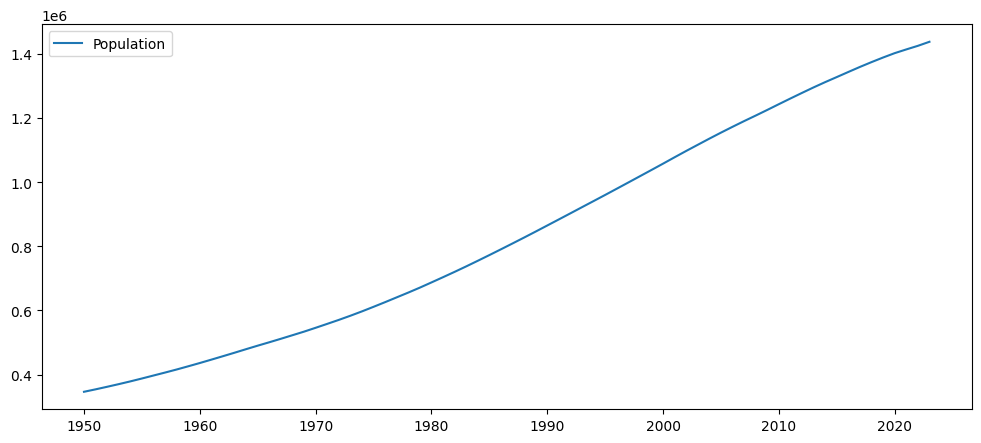

In [125]:
plt.figure(figsize=(12,5))
plt.plot(india['Year'], india['Total Population, as of 1 July (thousands)'], label='Population')
plt.legend()
plt.show()

/tmp/ipykernel_6762/2010113392.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india['Rolling Mean'] = india['Total Population, as of 1 July (thousands)'].rolling(window=5).mean()


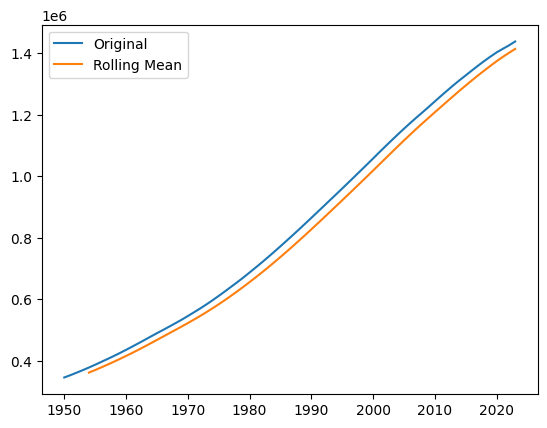

In [126]:
india['Rolling Mean'] = india['Total Population, as of 1 July (thousands)'].rolling(window=5).mean()

plt.plot(india['Year'], india['Total Population, as of 1 July (thousands)'], label='Original')
plt.plot(india['Year'], india['Rolling Mean'], label='Rolling Mean')
plt.legend()
plt.show()

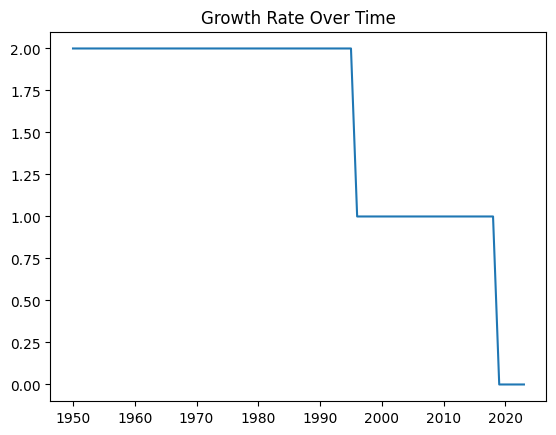

In [127]:
plt.plot(india['Year'], india['Population Growth Rate (percentage)'])
plt.title("Growth Rate Over Time")
plt.show()

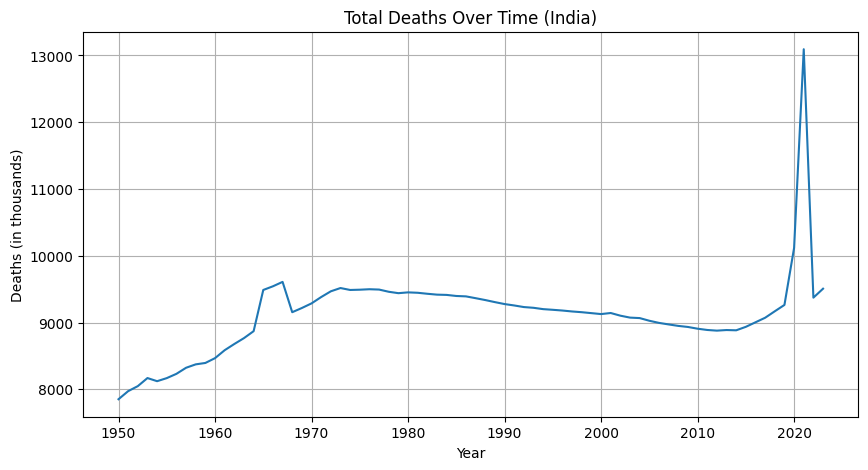

In [128]:
# Plot Deaths over time
plt.figure(figsize=(10,5))
plt.plot(india['Year'], india['Total Deaths (thousands)'])

plt.title("Total Deaths Over Time (India)")
plt.xlabel("Year")
plt.ylabel("Deaths (in thousands)")
plt.grid()

plt.show()

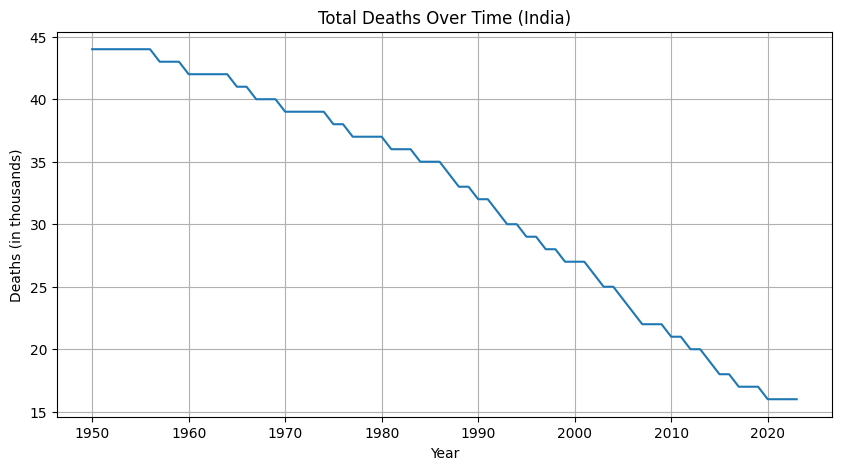

In [129]:

plt.figure(figsize=(10,5))
plt.plot(india['Year'], india['Crude Birth Rate (births per 1,000 population)'])

plt.title("Total Deaths Over Time (India)")
plt.xlabel("Year")
plt.ylabel("Deaths (in thousands)")
plt.grid()

plt.show()

/tmp/ipykernel_6762/2571766010.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india['Death Rate Rolling'] = india['Crude Birth Rate (births per 1,000 population)'].rolling(5).mean()


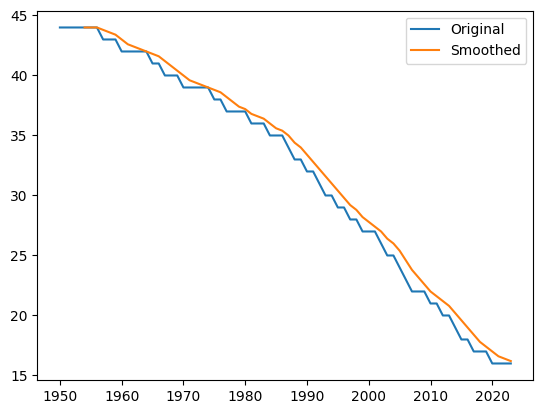

In [130]:
india['Death Rate Rolling'] = india['Crude Birth Rate (births per 1,000 population)'].rolling(5).mean()

plt.plot(india['Year'], india['Crude Birth Rate (births per 1,000 population)'], label='Original')
plt.plot(india['Year'], india['Death Rate Rolling'], label='Smoothed')

plt.legend()
plt.show()

In [131]:
india = india.set_index('Year')

In [134]:

timeseries = india['Total Population, as of 1 July (thousands)']

# Fit ARIMA model (e.g., ARIMA(5,1,0) - (p,d,q) - non-seasonal)

model = ARIMA(timeseries, order=(5,1,0))
model_fit = model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Usin

In [135]:
print(model_fit.summary())

                                           SARIMAX Results                                            
Dep. Variable:     Total Population, as of 1 July (thousands)   No. Observations:                   74
Model:                                         ARIMA(5, 1, 0)   Log Likelihood               -4334.814
Date:                                        Tue, 31 Mar 2026   AIC                           8681.628
Time:                                                07:55:04   BIC                           8695.370
Sample:                                                     0   HQIC                          8687.104
                                                         - 74                                         
Covariance Type:                                          opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0

In [150]:
forecast_steps = 10
forecast = model_fit.forecast(steps=forecast_steps)

forecast_index = range(
    timeseries.index[-1] + 1,
    timeseries.index[-1] + forecast_steps + 1
)

forecast_series = pd.Series(forecast, index=forecast_index)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [148]:
forecast_steps = 10
forecast = model_fit.forecast(steps=forecast_steps)

forecast_index = pd.date_range(
    start=timeseries.index[-1],
    periods=forecast_steps + 1,
    freq='Y'
)[1:]

forecast_series = pd.Series(forecast, index=forecast_index)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/tmp/ipykernel_6762/3532491317.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_index = pd.date_range(


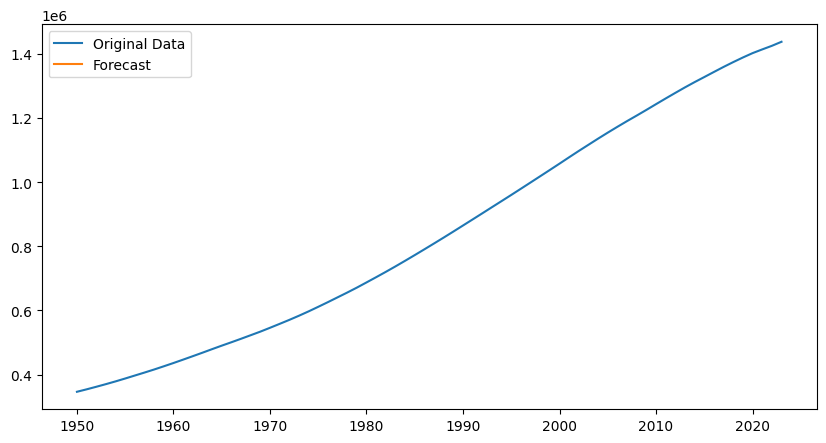

In [151]:

plt.figure(figsize=(10,5))

# Original data
plt.plot(timeseries, label='Original Data')

# Forecast
plt.plot(forecast_series, label='Forecast')

plt.legend()
plt.show()


In [152]:
print("Last original index:", timeseries.index[-1])
print("Forecast index:", forecast_series.index[:5])

Last original index: 2023
Forecast index: RangeIndex(start=2024, stop=2029, step=1)


In [153]:
print(forecast_series)

2024   NaN
2025   NaN
2026   NaN
2027   NaN
2028   NaN
2029   NaN
2030   NaN
2031   NaN
2032   NaN
2033   NaN
Name: predicted_mean, dtype: float64


In [155]:
print(timeseries.isna().sum())

0
